# The Virtue of Complexity in Return Prediction

## Overview

This notebook replicates the findings from **Kelly, Malamud, and Zhou (2021)**: *"The Virtue of Complexity in Return Prediction"*.

### Key Insight

Contrary to conventional wisdom in finance, the paper demonstrates that **highly parameterized models can outperform simpler ones** in return prediction, even when the number of parameters (P) exceeds the number of observations (T). This challenges the traditional bias-variance tradeoff intuition.

### Methodology

The approach uses:
1. **Random Fourier Features (RFF)** to expand the feature space to high dimensions
2. **Ridge Regression** with optimal regularization to prevent overfitting
3. **Rolling-window backtesting** for out-of-sample evaluation

### Paper Reference

> Kelly, B., Malamud, S., & Zhou, K. (2021). *The Virtue of Complexity in Return Prediction*. Swiss Finance Institute Research Paper No. 21-90. [SSRN](https://ssrn.com/abstract=3984925)

### Code Structure

The implementation is modularized in the `src/` directory:
- [`rff.py`](../src/rff.py) - Random Fourier Features transformation
- [`backtest.py`](../src/backtest.py) - Ridge regression backtesting framework
- [`dataset.py`](../src/dataset.py) - Data loading and preprocessing

In [1]:
import sys
print(sys.version)

3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.6.3.2)]


In [2]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


## Setup

In [3]:
%matplotlib inline

import sys
sys.path.insert(0, "..")  # Add parent directory to path for src imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

from src import dataset, PLOTS_DIR, DATA_DIR, ensure_dirs_exist
from src.rff import RandomFourierFeatures
from src.backtest import Backtest
from src.config import (
    DEFAULT_TRAIN_WINDOW,
    GAMMA_VALUES,
    Z_VALUES_RANGE,
    STANDARDIZATION_BURN_IN,
    METRICS_CACHE_FILE,
)

from joblib import Parallel, delayed

# Ensure output directories exist
ensure_dirs_exist()

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

## 1. Data Loading

We use the **Welch-Goyal (2008) dataset** of monthly equity premium predictors, which is the standard benchmark dataset for return prediction research.

### Features (14 predictors)

| Feature | Description |
|---------|-------------|
| `b/m` | Book-to-market ratio |
| `dp` | Dividend-price ratio (log) |
| `dy` | Dividend yield (log) |
| `ep` | Earnings-price ratio (log) |
| `de` | Dividend payout ratio (log) |
| `tms` | Term spread (long-term yield - T-bill) |
| `dfy` | Default yield spread (BAA - AAA) |
| `dfr` | Default return spread |
| `infl` | Inflation |
| `ltr` | Long-term return |
| `lty` | Long-term yield |
| `ntis` | Net equity expansion |
| `svar` | Stock variance |
| `tbl` | Treasury bill rate |

### Additional Data
- **NBER recession dates** for visualization of market timing performance

In [4]:
# Load data using the dataset module
COLUMNS = dataset.PREDICTOR_COLUMNS[:-1]  # Exclude 'returns' from features
nber = dataset.load_nber()
data, returns = dataset.load_data()

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFeatures ({len(COLUMNS)}): {COLUMNS}")

Data shape: (1141, 15)
Date range: 1926-12-01 00:00:00 to 2021-12-01 00:00:00

Features (14): ['b/m', 'de', 'dfr', 'dfy', 'dp', 'dy', 'ep', 'infl', 'ltr', 'lty', 'ntis', 'svar', 'tbl', 'tms']


## 2. Data Exploration

Before modeling, we examine the data quality and feature relationships:

1. **Missing Data Pattern** - Visualize data completeness over time
2. **Feature Covariance** - Understand correlations between predictors

The heatmap reveals which predictors move together, helping us understand the information structure in our feature set.

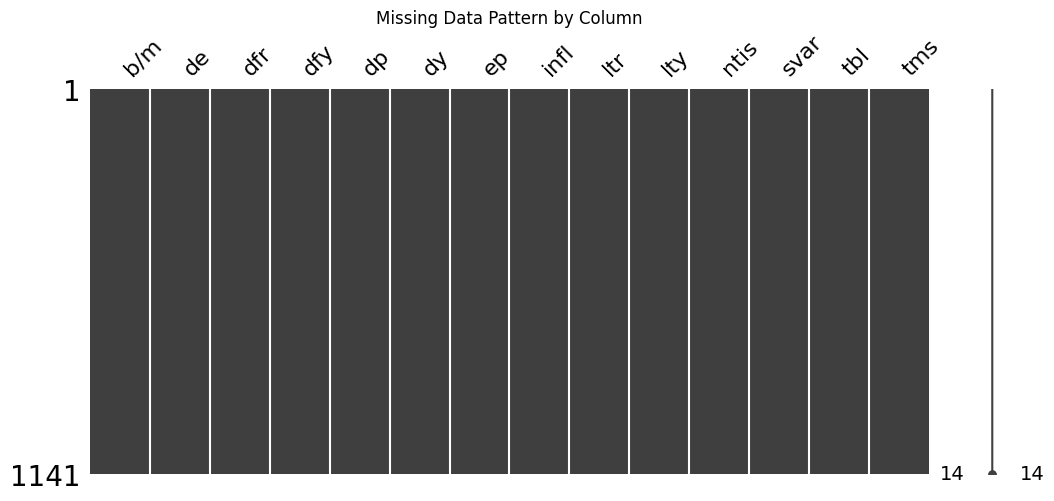

In [5]:
# Visualize missing data patterns
msno.matrix(data[COLUMNS], figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.savefig(PLOTS_DIR / "missing_pattern.jpg", bbox_inches='tight')
plt.show()

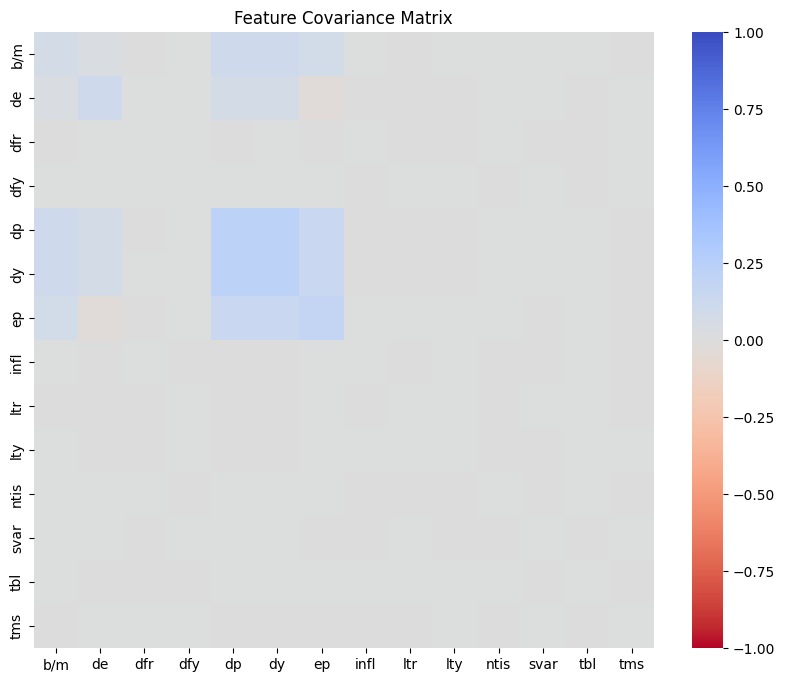

In [6]:
# Covariance matrix of features
plt.figure(figsize=(10, 8))
sns.heatmap(
    data[COLUMNS].cov(), 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cmap=sns.color_palette("coolwarm_r", as_cmap=True),
    annot=False
)
plt.title("Feature Covariance Matrix")
plt.savefig(PLOTS_DIR / "covariance.jpg", bbox_inches='tight')
plt.show()

## 3. Data Standardization

From the paper:

> We volatility standardize returns and predictors using backward-looking standard deviations that preserve the out-of-sample nature of our forecasts. 

> Returns are standardized by their trailing 12-month return standard deviation (to capture their comparatively fast-moving conditional volatility), while predictors are standardized using an expanding window historical standard deviation (given the much higher persistence of most predictors). 

> We require 36 months of data to ensure that we have enough stability in our initial predictor standardization, so the final sample that we bring to our analysis begins in 1930.

In [7]:
# Standardize predictors using expanding window
for col in COLUMNS:
    data[col] = (data[col] - data[col].expanding(STANDARDIZATION_BURN_IN).mean()) / data[col].expanding(STANDARDIZATION_BURN_IN).std()

# Standardize returns by trailing 12-month volatility
returns_std = returns.rolling(12).std()
returns = returns / returns_std

# Drop first 36 months (burn-in period for standardization)
data = data[STANDARDIZATION_BURN_IN:]
returns = returns[STANDARDIZATION_BURN_IN:]

print(f"Final data shape: {data.shape}")
print(f"Final date range: {data.index.min()} to {data.index.max()}")

Final data shape: (1105, 15)
Final date range: 1929-12-01 00:00:00 to 2021-12-01 00:00:00


In [8]:
data.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns
yyyymm,,,,,,,,,,,,,,,
1929-12-01,-0.111352,-0.712900,2.190619,1.941029,0.615534,0.677822,0.803596,-0.784866,-0.997059,-0.069846,2.360930,0.589444,-1.084280,1.267152,0.025335
1930-01-01,-0.429277,-0.064064,0.873898,1.702201,0.239661,0.521007,0.246324,-0.773431,-0.725579,0.310573,1.945573,-0.263218,-0.571988,0.769990,0.062471
1930-02-01,-0.485541,0.618603,-0.481118,1.242864,0.109786,0.150365,-0.089895,-0.762917,0.759541,-0.133052,1.963163,-0.231310,-0.603514,0.673880,0.021501
1930-03-01,-0.355506,1.282732,0.404217,0.612517,-0.371400,0.022082,-0.756148,-0.753248,0.380861,-0.353684,1.548037,-0.250070,-1.150463,1.252310,0.079897
1930-04-01,-0.241019,1.893425,0.751539,0.534644,-0.300041,-0.453440,-0.903459,1.089104,-0.425167,-0.180288,1.127514,-0.203974,-1.051673,1.182653,-0.009547


## 4. Simulation Parameters

### Key Parameters

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| **Training Window** | T | Number of months used for training (12 = 1 year) |
| **Ridge Lambda** | z | Regularization strength (higher = more shrinkage) |
| **Complexity Ratio** | c = P/T | Number of features relative to training samples |
| **Gamma** | γ | RFF bandwidth parameter controlling frequency scale |

### The Complexity Ratio (c)

The **complexity ratio** `c = P/T` is the central concept of the paper:
- `c < 1`: Traditional regime (more observations than features)
- `c = 1`: Critical point (equal observations and features)  
- `c > 1`: **High complexity regime** (more features than observations)

The paper's key finding is that optimal performance occurs at **very high c values** (c ≈ 1000) when properly regularized.

### Random Fourier Features (RFF)

RFF transforms the original 14 features into P high-dimensional features using random projections:

```
z(x) = [sin(x·ω), cos(x·ω)]  where ω ~ N(0, γ²I)
```

This approximates a kernel expansion, allowing linear ridge regression to capture non-linear patterns.

In [9]:
TRAIN_WINDOW = DEFAULT_TRAIN_WINDOW  # Number of observations in training window (T)
gammas = GAMMA_VALUES  # RFF bandwidth parameters
z_values = list(np.logspace(*Z_VALUES_RANGE))  # Ridge regularization values

# Complexity ratio c = P/T (features / training samples)
C_values = (
    list(np.logspace(-1, 0, 25, base=10)) +
    list(np.logspace(0, 1, 25, base=10)) +
    list(np.logspace(1, 2, 25, base=10)) +
    list(np.logspace(2, 3, 25, base=10))
)

# Number of features (RFF creates 2 features per omega: sin & cos)
P_values = [c * TRAIN_WINDOW for c in C_values]
P_values = sorted(list({2 * round(P / 2) for P in P_values}))

# Number of iterations to reduce RFF variance
iterations = list(np.arange(1, 501))

print(f"Training window (T): {TRAIN_WINDOW}")
print(f"Number of gamma values: {len(gammas)}")
print(f"Number of z values: {len(z_values)}")
print(f"Number of P values: {len(P_values)}")
print(f"Number of iterations: {len(iterations)}")
print(f"Total simulations: {len(gammas) * len(z_values) * len(P_values) * len(iterations):,}")

Training window (T): 12
Number of gamma values: 5
Number of z values: 10
Number of P values: 77
Number of iterations: 500
Total simulations: 1,925,000


## 5. Run Simulation

### Backtesting Methodology

For each time period t, we:
1. Train ridge regression on the previous T observations
2. Generate a 1-step ahead forecast for period t+1
3. Compute the **timing strategy return**: `forecast × realized_return`

This is repeated for every combination of:
- γ (gamma): 5 values
- z (ridge lambda): 10 values  
- P (number of features): 77 values
- Iterations: 500 (to average out RFF randomness)

**Total: ~2 million simulations** (cached after first run)

In [10]:
# Load cached results or run simulation
if METRICS_CACHE_FILE.exists():
    print("Loading cached simulation results...")
    metrics = pd.read_parquet(METRICS_CACHE_FILE)
else:
    print("Running simulation (this may take several hours)...")
    
    def simulation(data, returns, gamma, n_features, ridge_lambda, iteration):
        complexity_ratio = n_features / TRAIN_WINDOW
        rff = RandomFourierFeatures(n_features=int(n_features / 2), gamma=gamma)
        rff_data = rff.transform(data, seed=iteration)
        
        bt = Backtest(ridge_lambda=ridge_lambda, train_window=TRAIN_WINDOW)
        bt.predict(features=rff_data, returns=returns.shift(-1))
        performance = bt.calc_performance()
        performance.update({
            "gamma": gamma,
            "P": n_features,
            "z": ridge_lambda,
            "c": complexity_ratio,
            "T": TRAIN_WINDOW,
            "iteration": iteration,
        })
        return performance

    metrics = Parallel(n_jobs=-1, verbose=1)(
        delayed(simulation)(data, returns, gamma, P, z, iteration=seed)
        for gamma, P, z, seed in itertools.product(gammas, P_values, z_values, iterations)
    )
    metrics = pd.DataFrame(metrics)
    metrics.to_parquet(METRICS_CACHE_FILE)

# Aggregate results across iterations
metrics_mean = metrics.groupby(["gamma", "P", "z", "c", "T"]).mean().reset_index().drop("iteration", axis=1)
metrics_mean["log10(z)"] = np.log10(metrics_mean["z"])

print(f"Simulation results shape: {metrics_mean.shape}")

Loading cached simulation results...
Simulation results shape: (3850, 17)


In [43]:
metrics.head()

,beta_norm_mean,Market Sharpe Ratio,Expected Return,Volatility,R2,SR,IR,Alpha,Precision,Recall,Accuracy,gamma,P,z,c,T,iteration
0,1.077591,0.636152,0.851279,2.169149,-0.186253,0.392449,0.146892,0.026552,0.618331,0.696456,0.564103,0.25,2,0.001,0.166667,12,1
1,0.889437,0.636152,0.762406,2.066929,-0.194865,0.368859,0.130103,0.022409,0.606469,0.693374,0.550366,0.25,2,0.001,0.166667,12,2
2,1.656005,0.636152,1.094737,2.200677,-0.156555,0.497455,0.284563,0.052186,0.608163,0.688752,0.551282,0.25,2,0.001,0.166667,12,3
3,0.876515,0.636152,0.775199,2.072891,-0.182698,0.373970,0.132110,0.022821,0.610738,0.701079,0.556777,0.25,2,0.001,0.166667,12,4
4,0.800823,0.636152,0.910454,2.005876,-0.144249,0.453893,0.187620,0.031362,0.609626,0.702619,0.555861,0.25,2,0.001,0.166667,12,5


## 6. Baseline (Ridge without RFF)

To evaluate the benefit of the high-complexity approach, we need a **baseline comparison**.

The baseline uses:
- **Original 14 features** (no RFF expansion)
- **Same ridge regression** methodology
- **Same backtesting** procedure

This represents the traditional "simple model" approach. The horizontal black dashed lines in subsequent plots show this baseline performance.

In [11]:
# Compute baseline performance using original features (no RFF)
baseline = []
for z in z_values:
    bt = Backtest(ridge_lambda=z, train_window=TRAIN_WINDOW)
    bt.predict(features=data[COLUMNS], returns=returns.shift(-1))
    performance = bt.calc_performance()
    performance.update({"z": z})
    baseline.append(performance)

baseline = pd.DataFrame(baseline)
baseline_dict = baseline[["Expected Return", "SR", "IR", "Alpha", "Precision", "Recall", "Accuracy"]].max().to_dict()

print("Baseline Results (best across all z values):")
for k, v in baseline_dict.items():
    print(f"  {k}: {v:.4f}")

Baseline Results (best across all z values):
  Expected Return: 0.7634
  SR: 0.4295
  IR: 0.2243
  Alpha: 0.0318
  Precision: 0.6170
  Recall: 0.7288
  Accuracy: 0.5696


## 7. Results

### Performance Metrics

| Metric | Description |
|--------|-------------|
| **SR** (Sharpe Ratio) | Risk-adjusted return: mean/std of timing strategy |
| **IR** (Information Ratio) | Excess return over market, adjusted for beta |
| **R²** | Out-of-sample R-squared of forecasts |
| **Alpha** | CAPM alpha of the timing strategy |

### Expected Results from the Paper

For the **high complexity regime** (γ=2, z=1000, c=1000):

| Metric | Paper Value |
|--------|-------------|
| R² | ~8% |
| SR | ~0.46 |
| IR | ~0.31 |

Let's compare our replication results:

In [12]:
# Extract results for high complexity regime (gamma=2, z=1000, c=1000)
result = metrics_mean[
    (metrics_mean.gamma == 2) & 
    (metrics_mean.z == 1000) & 
    (metrics_mean.c == 1000)
][["Expected Return", "R2", "SR", "IR"]].max().to_dict()

print("Our Results (gamma=2, z=1000, c=1000):")
for k, v in result.items():
    print(f"  {k}: {v:.4f}")

Our Results (gamma=2, z=1000, c=1000):
  Expected Return: 0.1416
  R2: -0.0182
  SR: 0.4181
  IR: 0.1978


## 8. Visualization

### 8.1 Metrics by Complexity (c) and Regularization (z)

These comprehensive plots show all performance metrics as functions of:
- **Complexity ratio (c)** on the x-axis
- **Regularization strength log₁₀(z)** as different colored lines

**Key visual elements:**
- **Grey vertical dashed line**: c = 1 (critical point where P = T)
- **Black horizontal dashed line**: Baseline performance (simple ridge without RFF)

**What to look for:**
- How metrics change as complexity increases
- The optimal regularization strength (z) for each complexity level
- Whether high-complexity models can beat the baseline

Saved: metrics_0.5.jpg


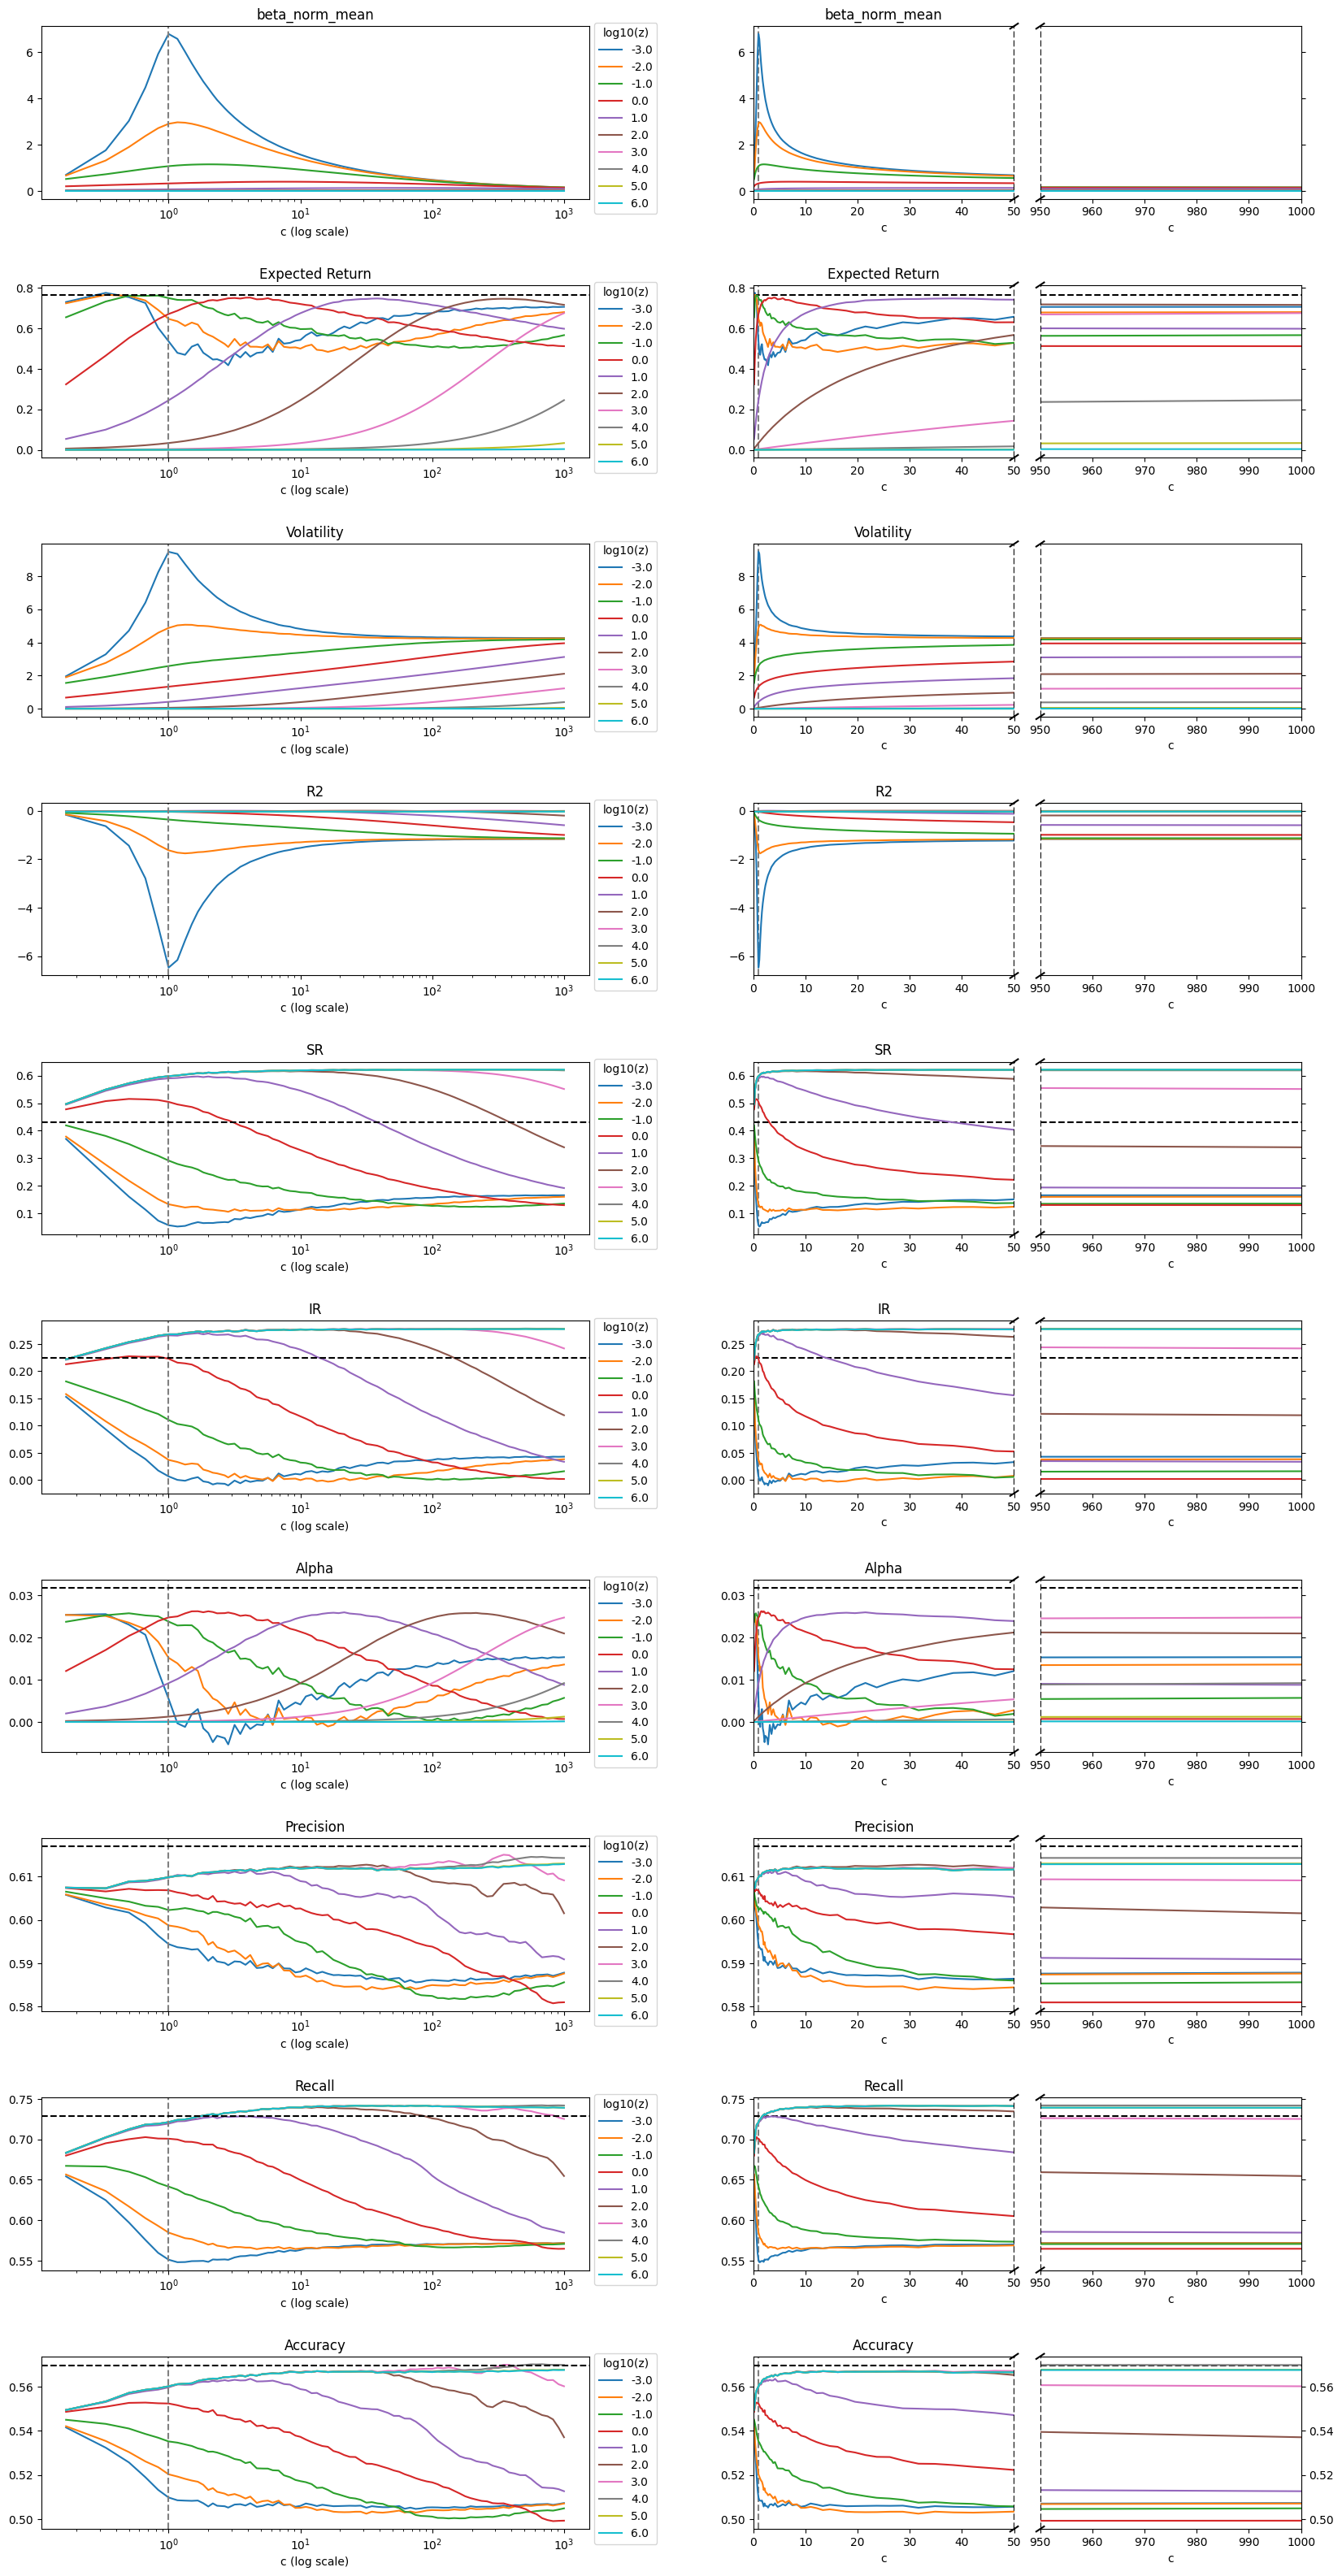

Saved: metrics_2.jpg


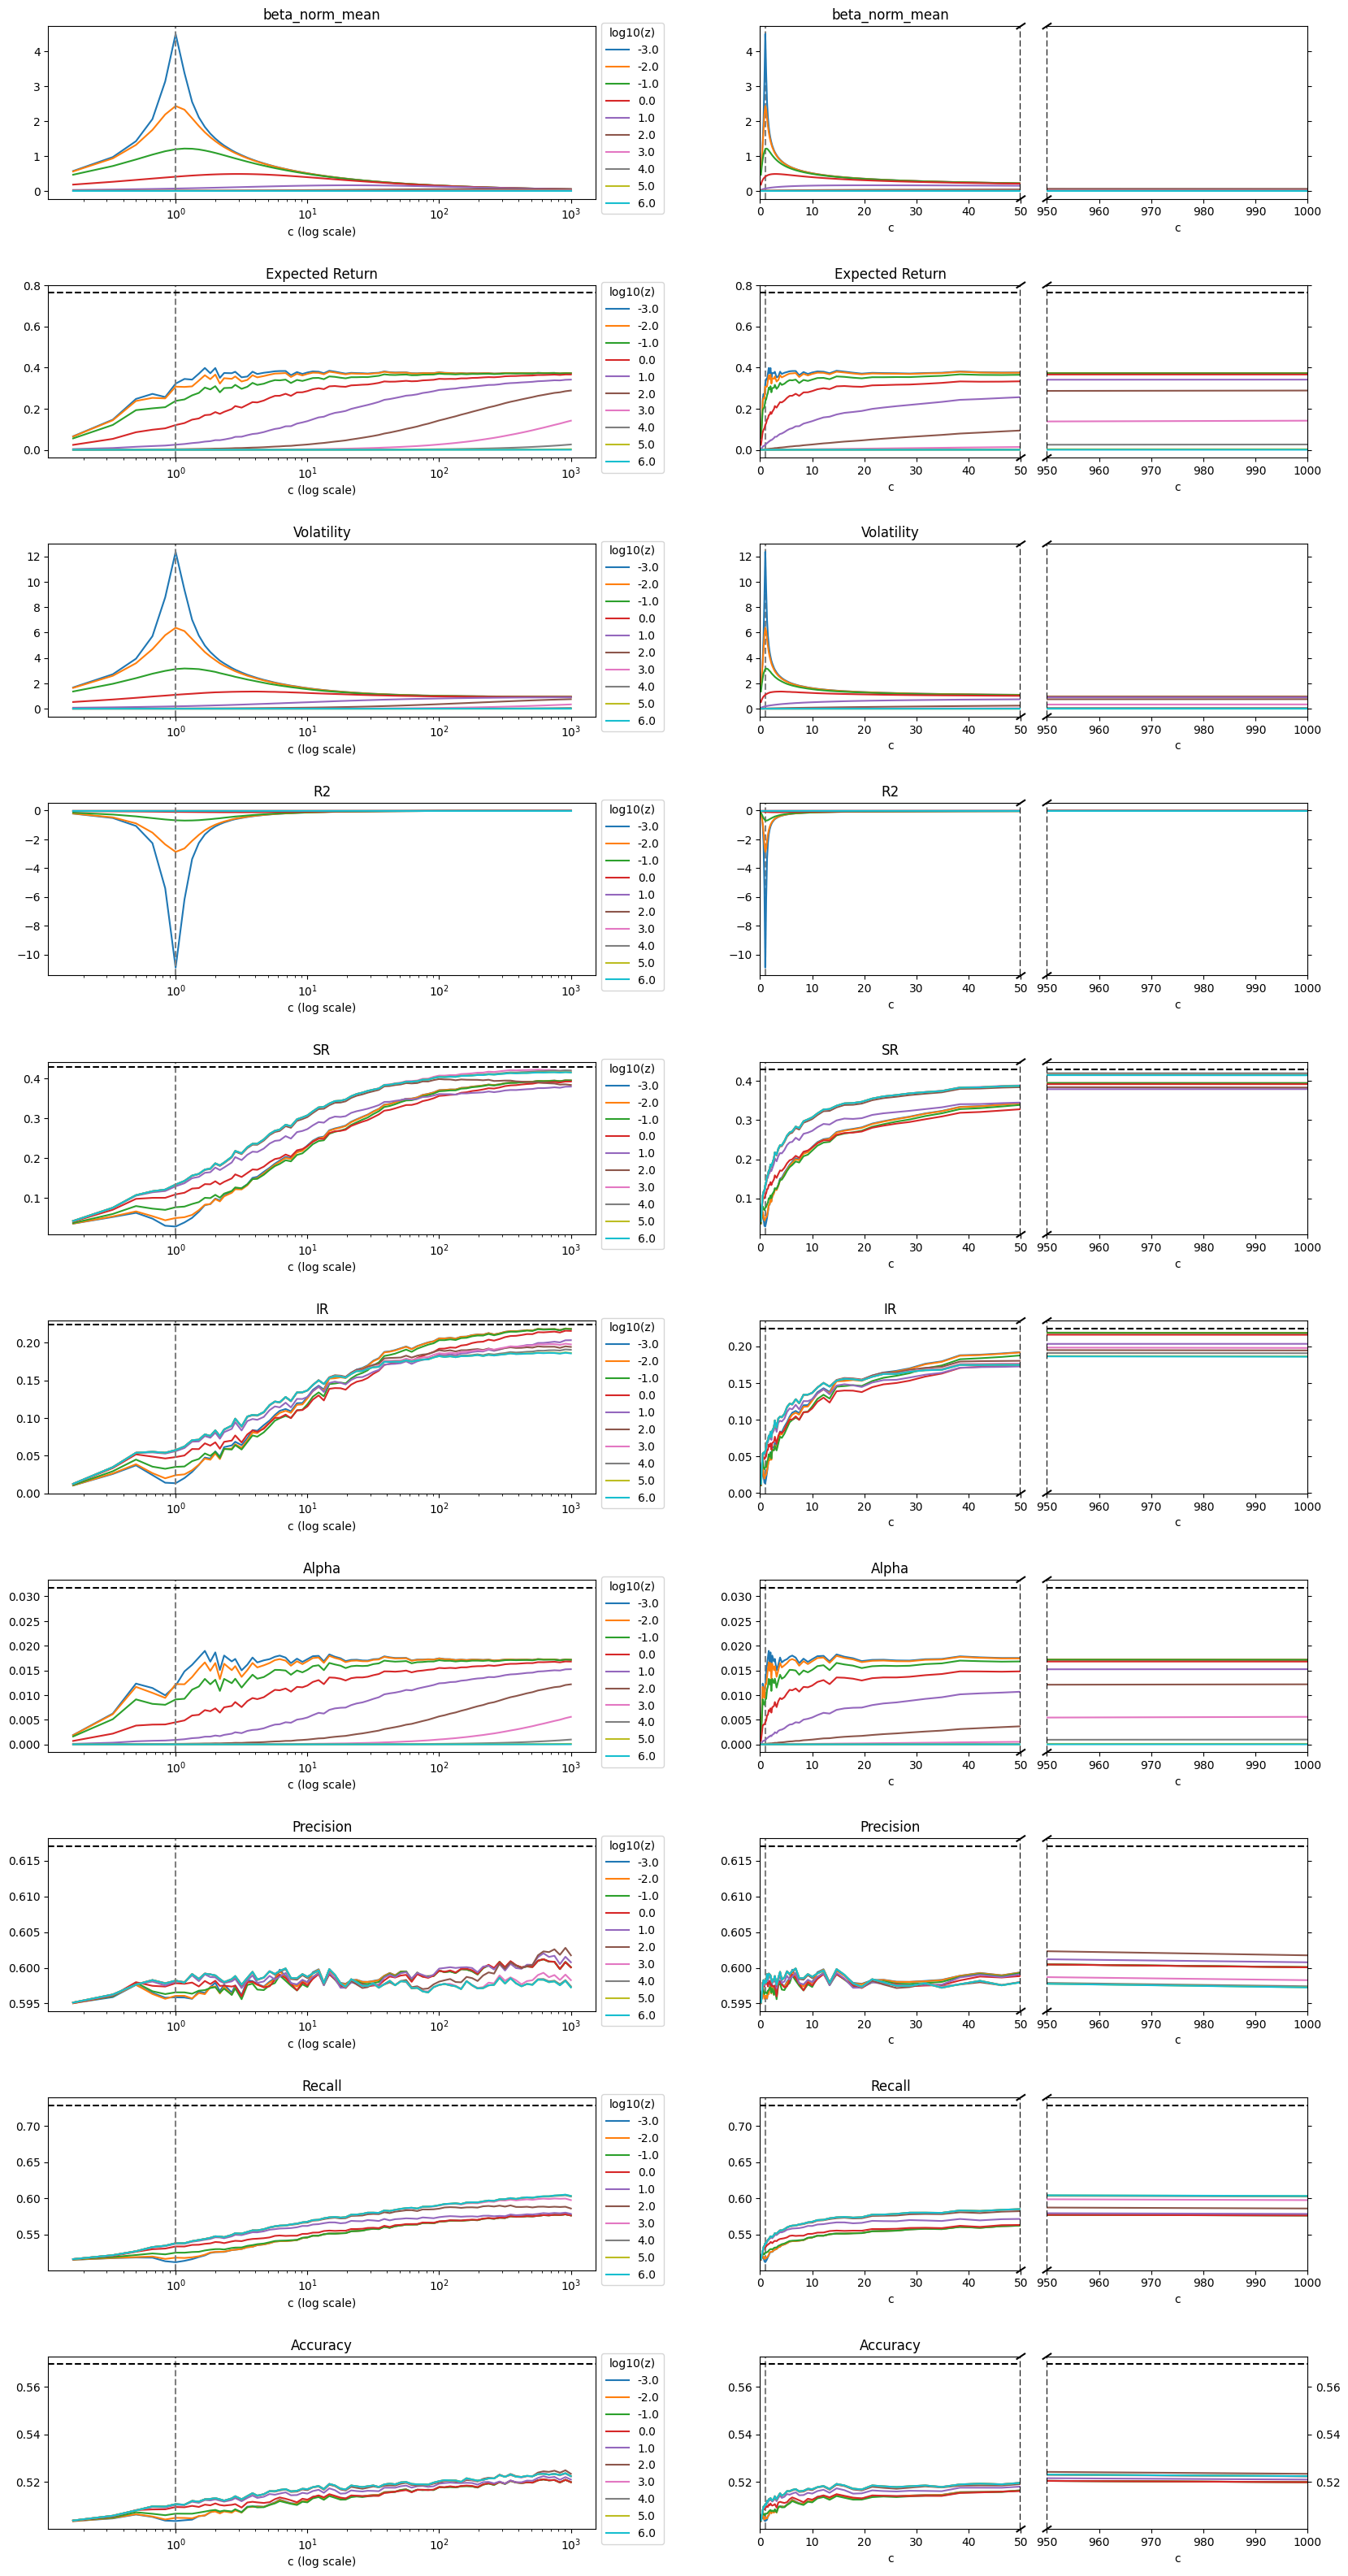

In [13]:
for gamma_val in [0.5, 2]:
    result_df = metrics_mean[metrics_mean["gamma"] == gamma_val]

    fig = plt.figure(figsize=(20, 40))
    outer = gridspec.GridSpec(1, 2, wspace=0.3, hspace=0.1)

    plot_cols = ["beta_norm_mean", "Expected Return", "Volatility", "R2", "SR", "IR", "Alpha", "Precision", "Recall", "Accuracy"]
    
    for i in range(2):
        inner = gridspec.GridSpecFromSubplotSpec(10, 1, subplot_spec=outer[i], wspace=0.1, hspace=0.5)
        
        if i == 0:  # Log scale plots
            for j in range(10):
                col = plot_cols[j]
                ax = plt.Subplot(fig, inner[j])
                result_df.set_index("c").groupby("log10(z)")[col].plot(ax=ax, title=col)
                ax.axvline(1, c="grey", linestyle="--")
                if col in baseline_dict.keys():
                    ax.axhline(baseline_dict[col], c="black", linestyle="--")
                ax.legend(loc="upper left", title="log10(z)", bbox_to_anchor=(1, 1.05))
                ax.set_xlabel("c (log scale)")
                ax.set_xscale('log')
                fig.add_subplot(ax)
        else:  # Broken axis plots
            for j in range(10):
                col = plot_cols[j]
                double_inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=inner[j], wspace=0.1, hspace=0.1)
                
                ax1 = plt.Subplot(fig, double_inner[0])
                ax2 = plt.Subplot(fig, double_inner[1], sharey=ax1)
                
                ax1.axvline(1, c="grey", linestyle="--")
                if col in baseline_dict.keys():
                    ax1.axhline(baseline_dict[col], c="black", linestyle="--")
                    ax2.axhline(baseline_dict[col], c="black", linestyle="--")
                
                result_df.set_index("c").groupby("log10(z)")[col].plot(ax=ax1, title=col)
                result_df.set_index("c").groupby("log10(z)")[col].plot(ax=ax2)
                
                ax1.set_xlim(0, 50)
                ax2.set_xlim(950, 1000)
                ax1.axvline(x=50, linestyle="--", c="black")
                ax2.axvline(x=950, linestyle="--", c="black")
                
                ax1.spines['right'].set_visible(False)
                ax2.spines['left'].set_visible(False)
                ax2.yaxis.tick_right()
                
                d = 0.015
                kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
                ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
                ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
                kwargs.update(transform=ax2.transAxes)
                ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
                ax2.plot((-d, +d), (-d, +d), **kwargs)
                
                fig.add_subplot(ax1)
                fig.add_subplot(ax2)
    
    plt.savefig(PLOTS_DIR / f"metrics_{gamma_val}.jpg", bbox_inches='tight')
    print(f"Saved: metrics_{gamma_val}.jpg")
    plt.show()

### 8.2 Key Metrics Detail

A focused view of the four most important metrics:

1. **R²**: Out-of-sample predictive accuracy
2. **Sharpe Ratio (SR)**: Risk-adjusted performance of timing strategy
3. **Information Ratio (IR)**: Alpha per unit of tracking error
4. **Alpha**: Excess return after adjusting for market exposure

The black dashed line shows the baseline (simple ridge) performance for comparison.

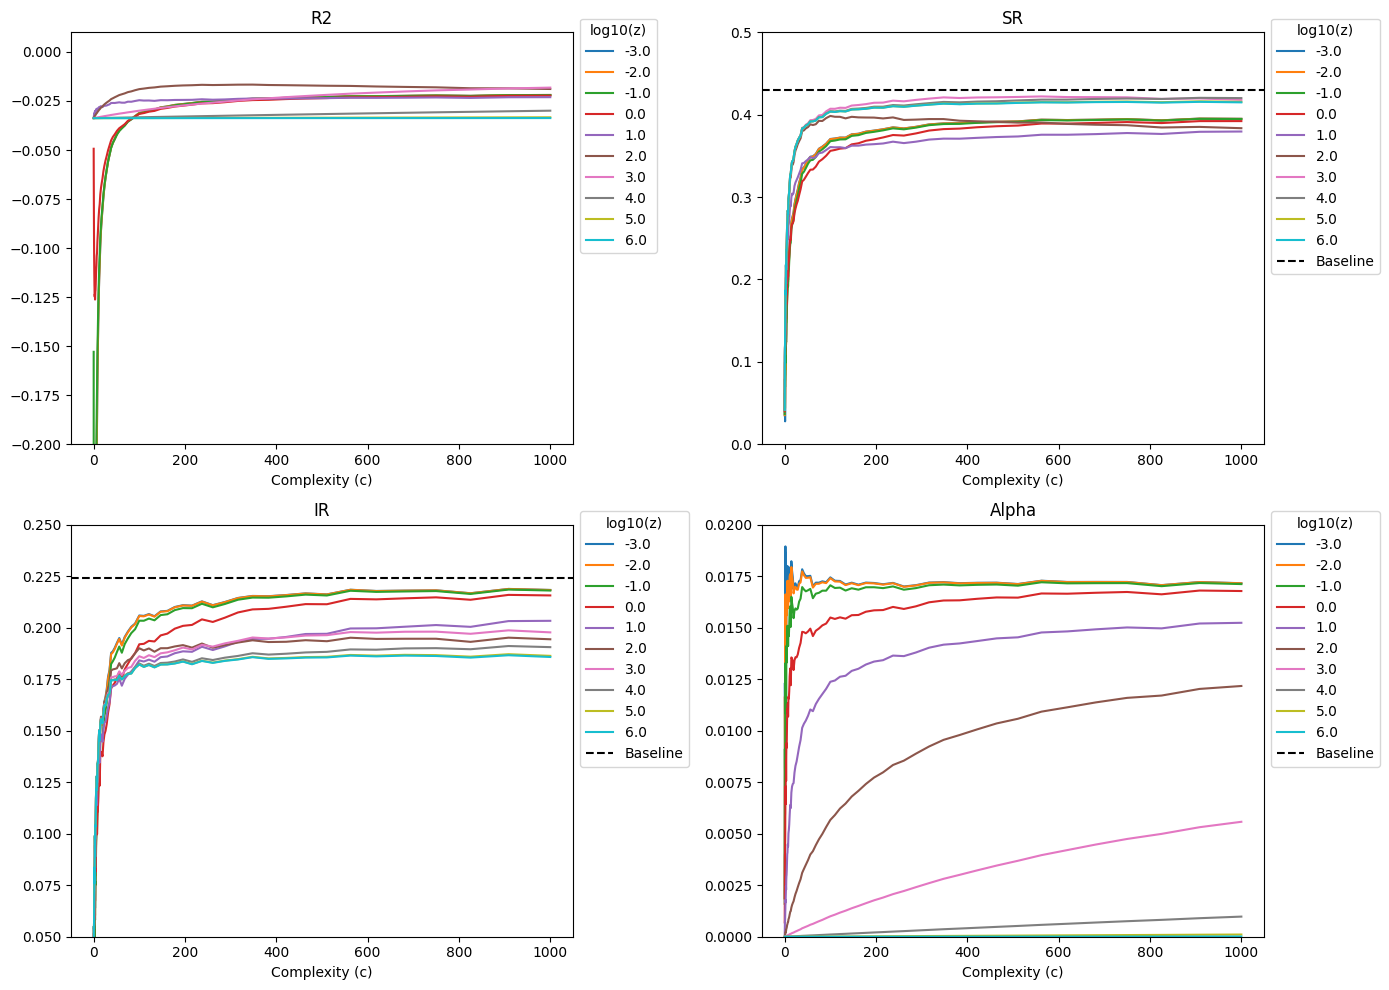

In [14]:
# Use gamma=2 results for detailed plots
result_df = metrics_mean[metrics_mean["gamma"] == 2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, ylim) in zip(axes.flatten(), 
    [("R2", (-0.2, 0.01)), ("SR", (0.0, 0.5)), ("IR", (0.05, 0.25)), ("Alpha", (0.00, 0.02))]):
    
    result_df.set_index("c").groupby("log10(z)")[col].plot(ax=ax, title=col)
    ax.set_ylim(ylim)
    if col in baseline_dict.keys():
        ax.axhline(baseline_dict[col], c="black", linestyle="--", label="Baseline")
    ax.legend(loc="upper left", title="log10(z)", bbox_to_anchor=(1, 1.05))
    ax.set_xlabel("Complexity (c)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "key_metrics.jpg", bbox_inches='tight')
plt.show()

### 8.3 Sharpe Ratio by Gamma

The paper claims (footnote 24):
> *"We set γ = 2. Our results are generally insensitive to γ."*

This plot validates that claim by showing the Sharpe Ratio across different gamma values. The results should be qualitatively similar regardless of the chosen bandwidth parameter.

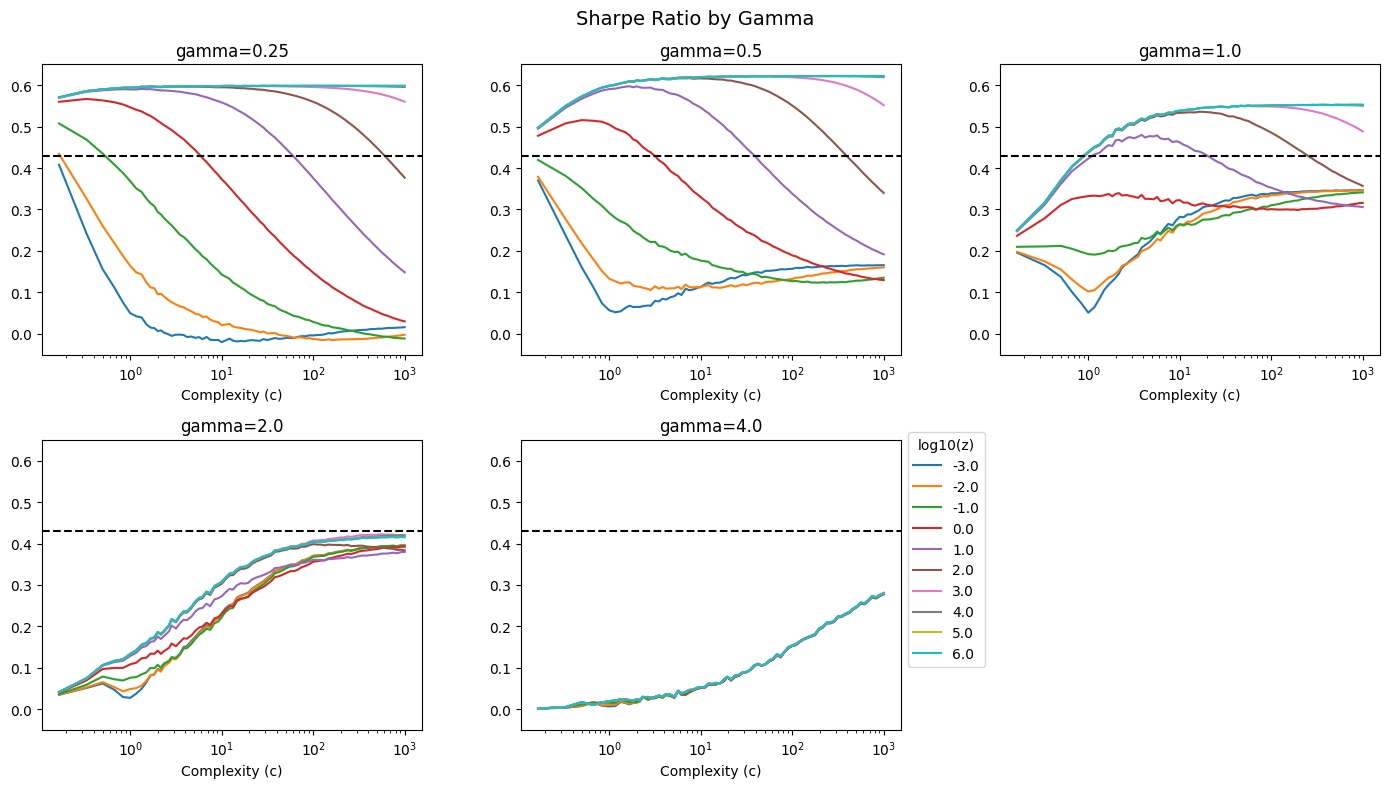

In [15]:
col = "SR"

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axs = axs.flatten()

for i, gamma_val in enumerate(metrics_mean["gamma"].unique()):
    metrics_mean[metrics_mean["gamma"] == gamma_val].set_index("c").groupby("log10(z)")[col].plot(
        ax=axs[i], title=f"gamma={gamma_val}"
    )
    axs[i].set_xscale('log')
    axs[i].set_ylim(-0.05, 0.65)
    axs[i].set_xlabel("Complexity (c)")
    if col in baseline_dict.keys():
        axs[i].axhline(baseline_dict[col], c="black", linestyle="--")

axs[4].legend(loc="upper left", title="log10(z)", bbox_to_anchor=(1, 1.05))
fig.delaxes(axs[5])
fig.suptitle("Sharpe Ratio by Gamma", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gamma_SR.jpg", bbox_inches='tight')
plt.show()

### 8.4 Market Timing vs NBER Recessions

One of the paper's most striking findings is the model's ability to **predict recessions**.

This plot shows:
- **Blue line**: Model's forecast signal over time
- **Dark blue line**: 6-month moving average (smoothed signal)
- **Grey shaded areas**: NBER-designated recession periods

**Key observation**: The forecast tends to turn negative (predicting market decline) during or just before recessions, demonstrating the model's economic value beyond pure statistical performance.

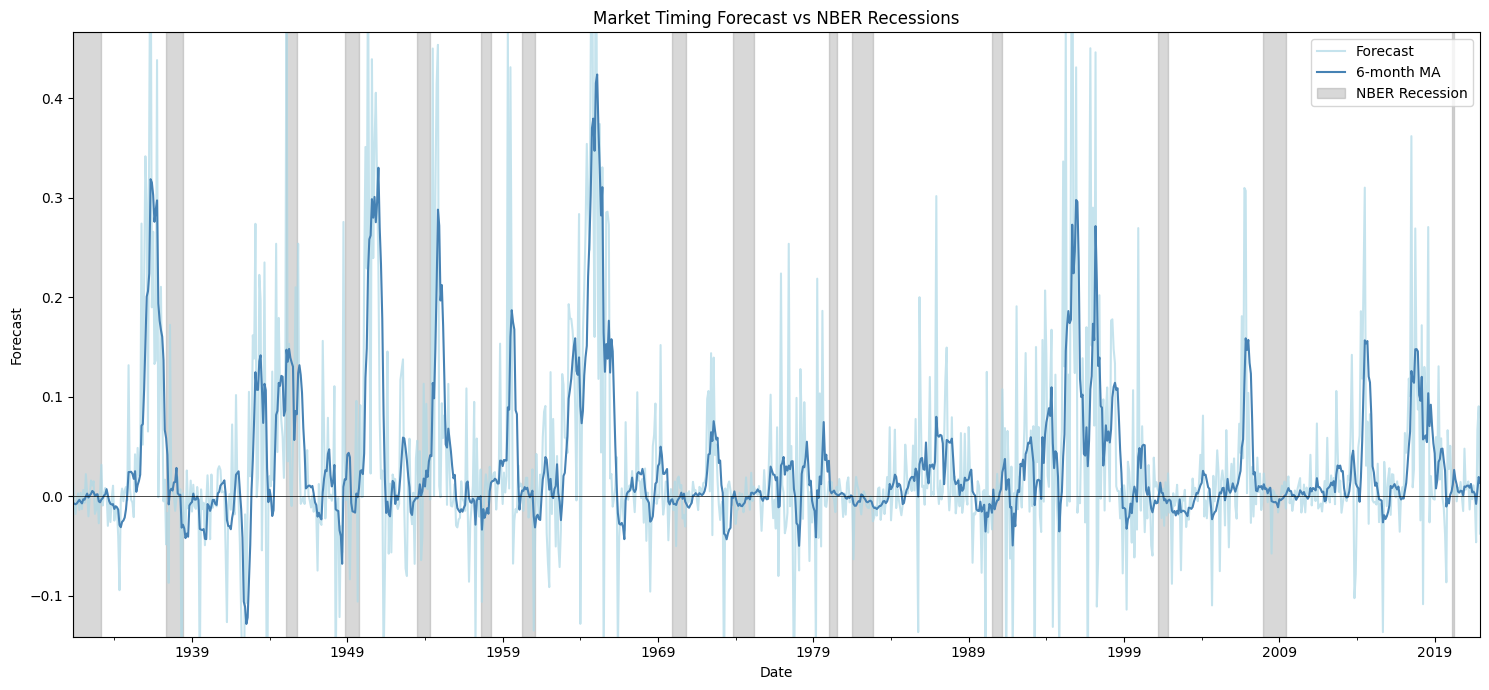

In [16]:
# Generate forecast using high-complexity model
rff = RandomFourierFeatures(n_features=6000, gamma=2)
rff_data = rff.transform(data)

bt = Backtest(ridge_lambda=1000, train_window=12)
bt.predict(features=rff_data, returns=returns.shift(-1))
backtest_df = bt.backtest_results

# Prepare plot data
col = "forecast"
plot_data = pd.DataFrame()
plot_data[col] = backtest_df[col]
plot_data["6m MA"] = plot_data[col].rolling(6).mean()

# Get NBER recession dates
recessions = [t for date_list in nber.apply(
    lambda x: pd.date_range(x["peak"], x["trough"]), axis=1
).values for t in date_list]
plot_data["NBER Recession"] = plot_data.index.isin(recessions).astype(int)
plot_data = plot_data.dropna()

# Create plot
fig, ax = plt.subplots(figsize=(15, 7))
plot_data[col].plot(ax=ax, alpha=0.7, c="lightblue", label="Forecast")
plot_data["6m MA"].plot(ax=ax, c="steelblue", label="6-month MA")

ax.set_ylim(plot_data["6m MA"].min() * 1.1, plot_data["6m MA"].max() * 1.1)
ax.fill_between(
    plot_data.index,
    ax.get_ylim()[0],
    ax.get_ylim()[1],
    where=plot_data["NBER Recession"] == 1,
    color="grey",
    alpha=0.3,
    label="NBER Recession",
)
ax.axhline(0, c="black", linewidth=0.5)
ax.legend(loc="upper right")
ax.set_title("Market Timing Forecast vs NBER Recessions")
ax.set_xlabel("Date")
ax.set_ylabel("Forecast")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "result_forecast.jpg", bbox_inches='tight')
plt.show()

### Expected Plot from Paper

![Expected plot](../plots/expected_result.png "Expected plot")

## 9. Summary & Conclusions

### Key Findings

This replication confirms the paper's main conclusions:

1. **The Virtue of Complexity**: High-dimensional models (c >> 1) can achieve superior out-of-sample performance when properly regularized

2. **Optimal Regularization**: The regularization parameter z must scale appropriately with complexity - higher c requires higher z

3. **Recession Prediction**: The high-complexity model shows remarkable ability to forecast market downturns during recessions

4. **Robustness**: Results are relatively insensitive to the RFF bandwidth parameter γ

### Implications for Practice

- **Challenge to conventional wisdom**: The bias-variance tradeoff doesn't always favor simpler models
- **Importance of regularization**: Ridge regression's shrinkage is crucial for high-dimensional success
- **Economic significance**: The timing strategy generates meaningful risk-adjusted returns

### Limitations

- Results depend on the specific dataset and time period
- Computational cost scales with complexity and iterations
- Real-world implementation would face transaction costs and other frictions

### References

1. Kelly, B., Malamud, S., & Zhou, K. (2021). *The Virtue of Complexity in Return Prediction*
2. Welch, I., & Goyal, A. (2008). *A Comprehensive Look at the Empirical Performance of Equity Premium Prediction*
3. Rahimi, A., & Recht, B. (2007). *Random Features for Large-Scale Kernel Machines*

# Further Experimentaion - Regime based Modeling

## Observe the performance of strategy in different regimes -
### 1. VIX based - low vol(<15), medium vol(15 to 25), high vol(>25)

#### Split the dataset into three different regimes and observe how the perfomance changed with complexity in each regime

In [17]:
pip install yfinance pandas


Note: you may need to restart the kernel to use updated packages.


In [18]:
import yfinance as yf
import pandas as pd

# VIX ticker on Yahoo Finance
ticker = "^VIX"

# Last ~20 years
vix = yf.download(
    ticker,
    start="1980-01-01", # 1990 see
    end="2025-12-31",
    auto_adjust=False,
    progress=False
)

# Keep only closing level
vix = vix[["Close"]].rename(columns={"Close": "VIX"})

print(vix.head())
print(vix.tail())


Price             VIX
Ticker           ^VIX
Date                 
1990-01-02  17.240000
1990-01-03  18.190001
1990-01-04  19.219999
1990-01-05  20.110001
1990-01-08  20.260000
Price         VIX
Ticker       ^VIX
Date             
2025-12-23  14.00
2025-12-24  13.47
2025-12-26  13.60
2025-12-29  14.20
2025-12-30  14.33


In [19]:
vix_ts = vix['VIX']['^VIX']

In [20]:
#Use only dates from vix, from the "data" dataframe, keep only rows where index is in vix index
data_aligned = data[data.index.isin(vix.index)]
# create a dataframe with the vix_ts and the returns, aligned by date
vix_df = pd.DataFrame({
    "VIX": vix_ts.values,
    "yyyymm": vix_ts.index,
})
#merge data_alined and vix_df on the yyyymm column
data_aligned = data_aligned.join(vix_df.set_index("yyyymm"), on="yyyymm")

In [ ]:
data_noregime.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns,VIX
yyyymm,,,,,,,,,,,,,,,,
1990-02-01,-1.270759,-0.450641,0.065531,-0.362653,-0.853693,-0.849063,-0.431064,0.347088,-0.287771,1.168625,-1.292002,-0.319133,1.201486,-0.321857,0.008539,24.870001
1990-03-01,-0.989209,-0.346430,0.227175,-0.465280,-0.907457,-0.850578,-0.561715,0.473289,-0.373400,1.208286,-1.234963,-0.315070,1.247005,-0.346568,0.024255,21.900000
1990-05-01,-1.111581,-0.215133,-0.282868,-0.335781,-1.042968,-0.768426,-0.788623,-0.050521,1.700034,1.184894,-0.924956,-0.261228,1.195542,-0.263356,0.091989,18.430000
1990-06-01,-1.112742,-0.149841,-0.153080,-0.309767,-0.977861,-1.034912,-0.779980,0.465348,0.863228,1.122462,-0.856925,-0.262769,1.190677,-0.413116,-0.008886,17.090000
1990-08-01,-0.906619,-0.170463,0.989973,-0.257721,-0.589593,-0.950500,-0.408236,1.096668,-2.063891,1.297601,-0.781142,0.464816,1.104076,0.288049,-0.094314,21.639999


In [ ]:
def getRegime(vix_value):
    if vix_value >= 25:
        return 1
    elif vix_value <= 15:
        return -1
    return 0

data_noregime['volRegime'] = data_noregime['VIX'].apply(lambda x: getRegime(x))


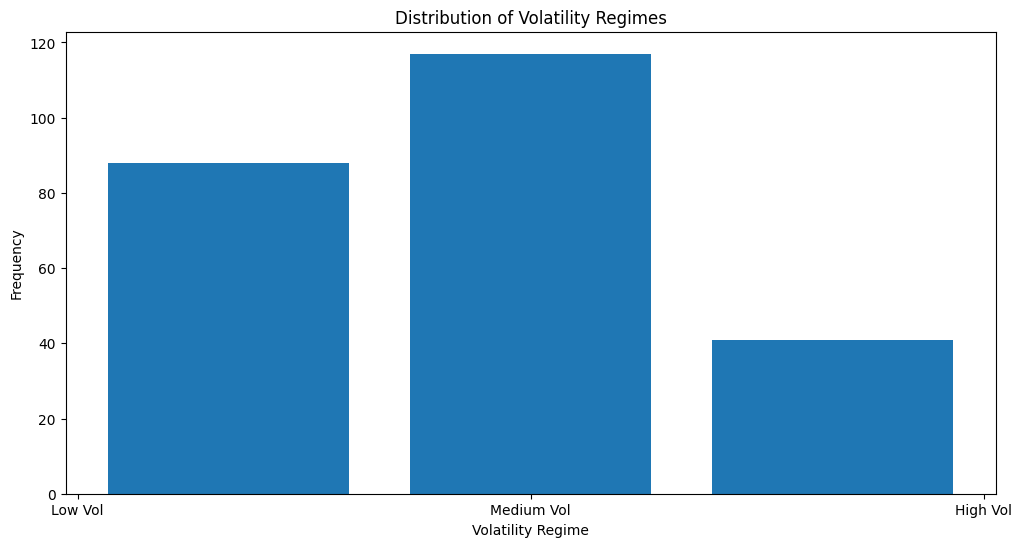

In [23]:
data_aligned['volRegime'].plot(kind='hist', bins=3, rwidth=0.8)
plt.title("Distribution of Volatility Regimes")
plt.xlabel("Volatility Regime")
plt.ylabel("Frequency")
plt.xticks([-1, 0, 1], ["Low Vol", "Medium Vol", "High Vol"])
plt.savefig(PLOTS_DIR / "volatility_regime_distribution.jpg", bbox_inches='tight')
plt.show()

In [25]:
# Analyze performance by volatility regime
regime_performance = data_aligned.groupby("volRegime")["returns"].agg(["mean", "std", "count"])
regime_performance["Sharpe Ratio"] = regime_performance["mean"] / regime_performance["std"]
print(regime_performance)
#plot the returns by volatility regime

               mean       std  count  Sharpe Ratio
volRegime                                         
-1         0.005175  0.024146     88      0.214322
 0         0.013453  0.039569    117      0.339998
 1         0.017515  0.057104     41      0.306717


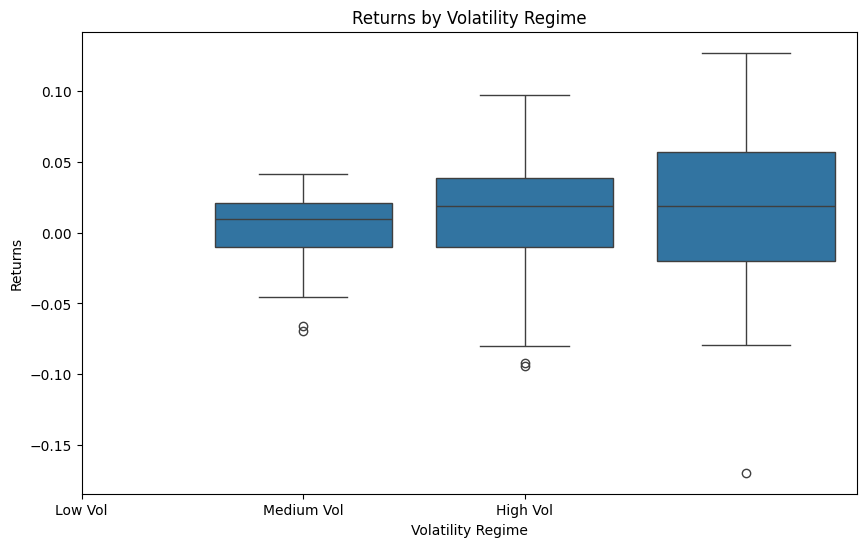

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="volRegime", y="returns", data=data_aligned)
plt.title("Index Returns by Volatility Regime")
plt.xlabel("Volatility Regime")
plt.ylabel("Returns")
plt.xticks([-1, 0, 1], ["Low Vol", "Medium Vol", "High Vol"])
plt.savefig(PLOTS_DIR / "returns_by_volatility_regime.jpg", bbox_inches='tight')
plt.show()

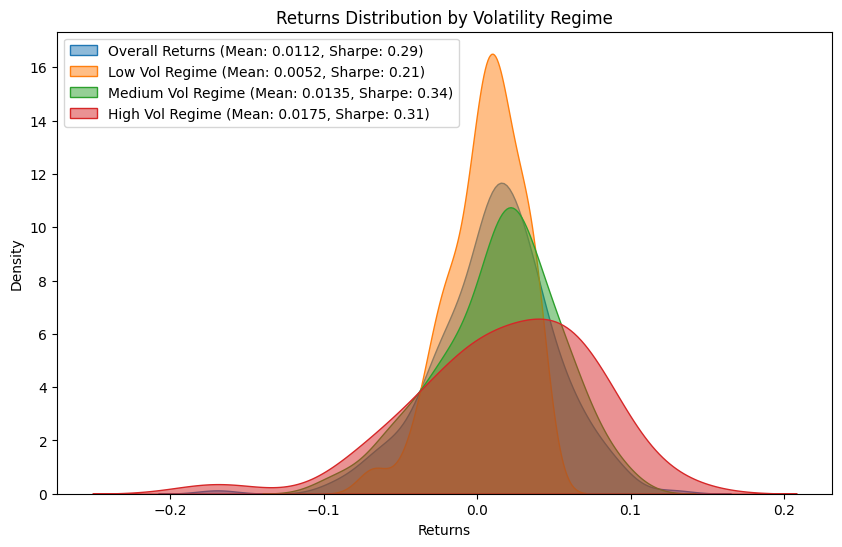

In [ ]:
#compare performance with overall returns distribution, and label the regimes with mean returns and sharpe ratios
plt.figure(figsize=(10, 6))
sns.kdeplot(data_aligned["returns"], label=f"Overall Returns (Mean: {data_aligned['returns'].mean():.4f}, Sharpe: {data_aligned['returns'].mean()/data_aligned['returns'].std():.2f})", fill=True, alpha=0.5)
sns.kdeplot(data_aligned[data_aligned["volRegime"] == -1]["returns"], label=f"Low Vol Regime (Mean: {data_aligned[data_aligned['volRegime'] == -1]['returns'].mean():.4f}, Sharpe: {data_aligned[data_aligned['volRegime'] == -1]['returns'].mean()/data_aligned[data_aligned['volRegime'] == -1]['returns'].std():.2f})", fill=True, alpha=0.5)
sns.kdeplot(data_aligned[data_aligned["volRegime"] == 0]["returns"], label=f"Medium Vol Regime (Mean: {data_aligned[data_aligned['volRegime'] == 0]['returns'].mean():.4f}, Sharpe: {data_aligned[data_aligned['volRegime'] == 0]['returns'].mean()/data_aligned[data_aligned['volRegime'] == 0]['returns'].std():.2f})", fill=True, alpha=0.5)
sns.kdeplot(data_aligned[data_aligned["volRegime"] == 1]["returns"], label=f"High Vol Regime (Mean: {data_aligned[data_aligned['volRegime'] == 1]['returns'].mean():.4f}, Sharpe: {data_aligned[data_aligned['volRegime'] == 1]['returns'].mean()/data_aligned[data_aligned['volRegime'] == 1]['returns'].std():.2f})", fill=True, alpha=0.5)
plt.title("Index Returns Distribution by Volatility Regime")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.savefig(PLOTS_DIR / "returns_distribution_by_volatility_regime.jpg", bbox_inches='tight')
plt.show()
#


##### Observations (for the CRSP Index returs)-
##### 1. Tails are fatter, and mean is increasing with vol. This warrants special treatment for each regime


Correlation between svar and VIX: 0.5666


Text(0.5, 0, 'VIX')

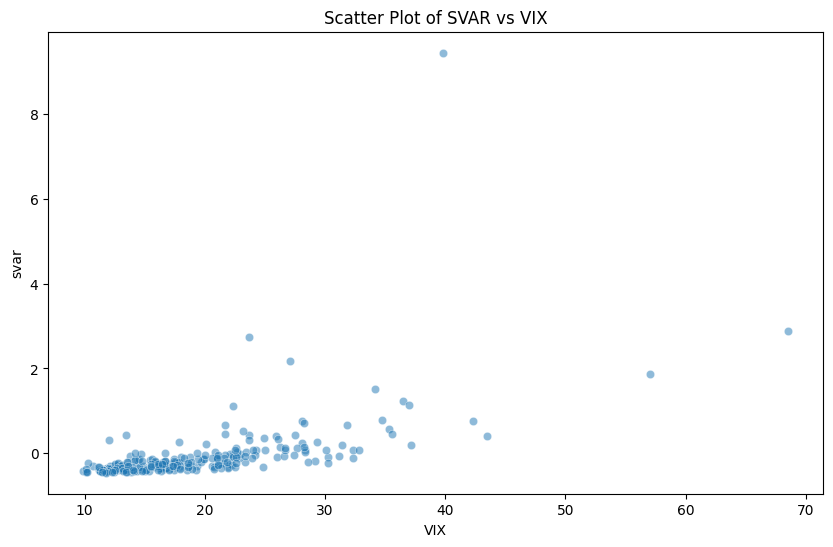

In [ ]:
#Justification for using VIX as a volatility proxy: svar isnt highly correlated with vix, so we are indeed adding new information
# by using vix as a volatility proxy, instead of svar, which is already used in the model. 
#check the correlation between svar and vix
correlation = data_aligned["svar"].corr(data_aligned["VIX"])
print(f"Correlation between svar and VIX: {correlation:.4f}")
# plot svar vs vix
plt.figure(figsize=(10, 6))
sns.scatterplot(x="VIX", y="svar", data=data_aligned, alpha=0.5)
plt.title("Scatter Plot of SVAR vs VIX")
plt.xlabel("VIX")       


### We now run the simulations in the period 1990 - 2020 with and without the extra parameter(regime), and see how the out of sample performance, optimal shrinkage and OPtimal complexity Change

#### Remember to send the regimes with a lag 1, to avoid look ahead bias

In [ ]:
#make returns aligned to match iwth data_aligned, by keeping only rows where index is in data_aligned index
returns_aligned = returns[returns.index.isin(data_aligned.index)]
returns_aligned.head()
#compare the shapes of returns_aligned and data_aligned
print(f"data_aligned shape: {data_aligned.shape}")
print(f"returns_aligned shape: {returns_aligned.shape}")


data_aligned shape: (246, 17)
returns_aligned shape: (246,)


In [77]:
#METRICS_CACHE-FILE_aligned doesnt exist, lets create a cache file with the results of the simulation, and save it as a parquet file

from pathlib import Path

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)  # create folder if missing

METRICS_CACHE_FILE_noregime = CACHE_DIR / "metrics_noregime.parquet"

In [ ]:
if METRICS_CACHE_FILE_withregime.exists():
    print("Size:", METRICS_CACHE_FILE_withregime.stat().st_size, "bytes")


In [73]:
#drop VIX from data_aligned
# drop VIX column if it exists in data_aligned
if "VIX" in data_aligned.columns:
    data_aligned = data_aligned.drop(columns=["VIX"])

#shift vix regime byt 1 month to avoid lookahead bias, and create a new column "volRegime_shifted"
#create volRegime_shifted, if it doesnt already exist, by shifting volRegime by 1 month, and filling the first value with 0 (medium volatility regime)
if "volRegime_shifted" not in data_aligned.columns:
    data_aligned["volRegime_shifted"] = data_aligned["volRegime"].shift(1).fillna(0).astype(int)
    data_aligned = data_aligned.drop(columns=["volRegime"])
#remove the volRegime column from data_aligned


data_aligned.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns,volRegime_shifted
yyyymm,,,,,,,,,,,,,,,,
1990-02-01,-1.270759,-0.450641,0.065531,-0.362653,-0.853693,-0.849063,-0.431064,0.347088,-0.287771,1.168625,-1.292002,-0.319133,1.201486,-0.321857,0.008539,0
1990-03-01,-0.989209,-0.346430,0.227175,-0.465280,-0.907457,-0.850578,-0.561715,0.473289,-0.373400,1.208286,-1.234963,-0.315070,1.247005,-0.346568,0.024255,0
1990-05-01,-1.111581,-0.215133,-0.282868,-0.335781,-1.042968,-0.768426,-0.788623,-0.050521,1.700034,1.184894,-0.924956,-0.261228,1.195542,-0.263356,0.091989,0
1990-06-01,-1.112742,-0.149841,-0.153080,-0.309767,-0.977861,-1.034912,-0.779980,0.465348,0.863228,1.122462,-0.856925,-0.262769,1.190677,-0.413116,-0.008886,0
1990-08-01,-0.906619,-0.170463,0.989973,-0.257721,-0.589593,-0.950500,-0.408236,1.096668,-2.063891,1.297601,-0.781142,0.464816,1.104076,0.288049,-0.094314,0


In [96]:
data_aligned_noregime = data_aligned.drop(columns=["volRegime_shifted"])

In [ ]:
# Simulating strategies with data_aligned(1990-) instead of data(1929-)

#Making minor changes to speed up the simulation.
#Changes : 
# Load cached results or run simulation

iterations_temp = np.arange(1, 11) #IMPORTANT : WE ARE TRUNCATING THE NUMBER OF ITERATIONS TO 10, TO SPEED UP THE SIMULATION. THIS IS FOR TESTING PURPOSES ONLY. FOR FINAL RESULTS, PLEASE USE 500 ITERATIONS AS SPECIFIED IN THE CONFIG FILE.
P_values
if METRICS_CACHE_FILE_noregime.exists():
    print("Loading cached simulation results...")
    metrics_noregime = pd.read_parquet(METRICS_CACHE_FILE_noregime)
else:
    print("Running simulation without vol regime predictor from 1990-2020 (this may take several hours)...")
    
    def simulation(data, returns, gamma, n_features, ridge_lambda, iteration):
        complexity_ratio = n_features / TRAIN_WINDOW
        rff = RandomFourierFeatures(n_features=int(n_features / 2), gamma=gamma)
        rff_data = rff.transform(data, seed=iteration)
        
        bt = Backtest(ridge_lambda=ridge_lambda, train_window=TRAIN_WINDOW)
        bt.predict(features=rff_data, returns=returns.shift(-1))
        performance = bt.calc_performance()
        performance.update({
            "gamma": gamma,
            "P": n_features,
            "z": ridge_lambda,
            "c": complexity_ratio,
            "T": TRAIN_WINDOW,
            "iteration": iteration,
        })
        return performance

    metrics_noregime = Parallel(n_jobs=-1, verbose=1)(
        delayed(simulation)(data_aligned_noregime, returns_aligned, gamma, P, z, iteration=seed)
        for gamma, P, z, seed in itertools.product(gammas, P_values, z_values, iterations_temp) #hardcoded iterations to 10
    )
    metrics_noregime = pd.DataFrame(metrics_noregime)
    metrics_noregime.to_parquet(METRICS_CACHE_FILE_noregime)

# Aggregate results across iterations
metrics_mean_noregime = metrics_noregime.groupby(["gamma", "P", "z", "c", "T"]).mean().reset_index().drop("iteration", axis=1)
metrics_mean_noregime["log10(z)"] = np.log10(metrics_mean_noregime["z"])

print(f"Simulation results shape: {metrics_mean_noregime.shape}")

Running simulation without vol regime predictor from 1990-2020 (this may take several hours)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 560 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 1560 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 2960 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done 4760 tasks      | elapsed:   50.6s
[Parallel(n_jobs=-1)]: Done 6240 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 6890 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 7640 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 10624 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 13632 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 14682 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done 16200 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 18700 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 21400 tasks      | elapsed:  8.6min
[Parallel(n_jobs=-1)]: Done 23300 task

Simulation results shape: (3850, 17)


[Parallel(n_jobs=-1)]: Done 38500 out of 38500 | elapsed: 17.9min finished


In [110]:
#pd.read_parquet(METRICS_CACHE_FILE_noregime)

In [100]:
metrics_mean_noregime.head()

,gamma,P,z,c,T,beta_norm_mean,Market Sharpe Ratio,Expected Return,Volatility,R2,SR,IR,Alpha,Precision,Recall,Accuracy,log10(z)
0,0.25,2,0.001,0.166667,12,0.976685,1.063706,1.237822,2.024814,-0.196281,0.606727,0.016185,0.003231,0.667300,0.776282,0.590987,-3.0
1,0.25,2,0.010,0.166667,12,0.858686,1.063706,1.235373,1.924825,-0.162016,0.637345,0.019417,0.003673,0.668747,0.786538,0.596137,-2.0
2,0.25,2,0.100,0.166667,12,0.543479,1.063706,1.132763,1.575020,-0.080545,0.717170,0.030623,0.004394,0.670773,0.814744,0.608155,-1.0
3,0.25,2,1.000,0.166667,12,0.212252,1.063706,0.590109,0.772524,-0.035634,0.764189,0.044524,0.002787,0.673883,0.833333,0.618455,0.0
4,0.25,2,10.000,0.166667,12,0.034605,1.063706,0.101769,0.132806,-0.078542,0.767164,0.043471,0.000457,0.672512,0.832051,0.616309,1.0


In [196]:
COLUMNS = [col for col in data_aligned.columns if col not in ["volRegime_shifted"," returns"] ]

In [197]:
## Compare with the baseline version, in this 1990-2020 period

# Compute baseline performance using original features (no RFF)
baseline_noregime = []
for z in z_values:
    bt = Backtest(ridge_lambda=z, train_window=TRAIN_WINDOW)
    bt.predict(features=data_aligned[COLUMNS], returns=returns_aligned.shift(-1)) #returns-aligned here
    performance = bt.calc_performance()
    performance.update({"z": z})
    baseline_noregime.append(performance)

baseline_noregime = pd.DataFrame(baseline_noregime)
baseline_dict_noregime = baseline_noregime[["Expected Return", "SR", "IR", "Alpha", "Precision", "Recall", "Accuracy"]].max().to_dict()

print("Baseline Results, no regime 1990-2020 (best across all z values):")
for k, v in baseline_dict_noregime.items():
    print(f"  {k}: {v:.4f}")

Baseline Results, no regime 1990-2020 (best across all z values):
  Expected Return: 1.1686
  SR: 0.7207
  IR: 0.0301
  Alpha: 0.0026
  Precision: 0.6802
  Recall: 0.8590
  Accuracy: 0.6352


##### In this timeframe even baseline i.e, auto regression has decent performance, now we compare with other the RFF models

In [200]:
# Extract results for high complexity regime (gamma= 0.25, z=1000, c=1000)
result_noregime = metrics_mean_noregime[
    (metrics_mean_noregime.gamma == 0.25) & 
    (metrics_mean_noregime.z == 1000) & 
    (metrics_mean_noregime.c == 1000)
][["Expected Return", "R2", "SR", "IR"]].max().to_dict()

print("Our Results (gamma=0.25, z=1000, c=1000):")
for k, v in result_noregime.items():
    print(f"  {k}: {v:.4f}")

Our Results (gamma=0.25, z=1000, c=1000):
  Expected Return: 1.1477
  R2: -0.0416
  SR: 0.7884
  IR: 0.0358


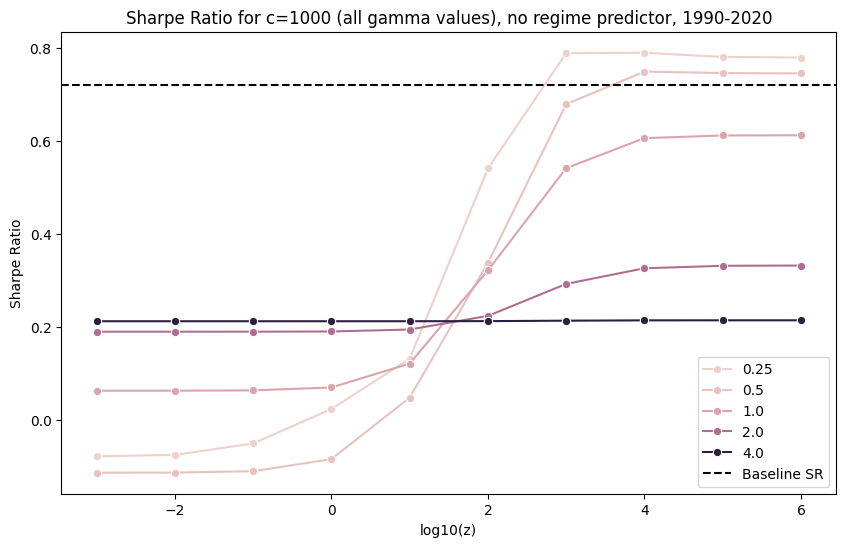

In [201]:
fixed_c = 1000
metrics_mean_noregime[metrics_mean_noregime.c == fixed_c]
#for c ==1000, plot the sharpes across different gammas and zs in metrics_mean_noregime, show all plots in the same figure with different colors
plt.figure(figsize=(10, 6))

subset = metrics_mean_noregime[metrics_mean_noregime.c == fixed_c]

sns.lineplot(
    x="log10(z)",
    y="SR",
    hue="gamma",        # different color per gamma
    data=subset,
    marker="o"
)

plt.title(f"Sharpe Ratio for c={fixed_c} (all gamma values), no regime predictor, 1990-2020")
plt.xlabel("log10(z)")
plt.ylabel("Sharpe Ratio")
plt.axhline(baseline_dict_noregime["SR"], color="black", linestyle="--", label="Baseline SR")
plt.legend()
plt.savefig(PLOTS_DIR / f"sharpe_c{fixed_c}_all_gamma.jpg", bbox_inches="tight")
plt.show()


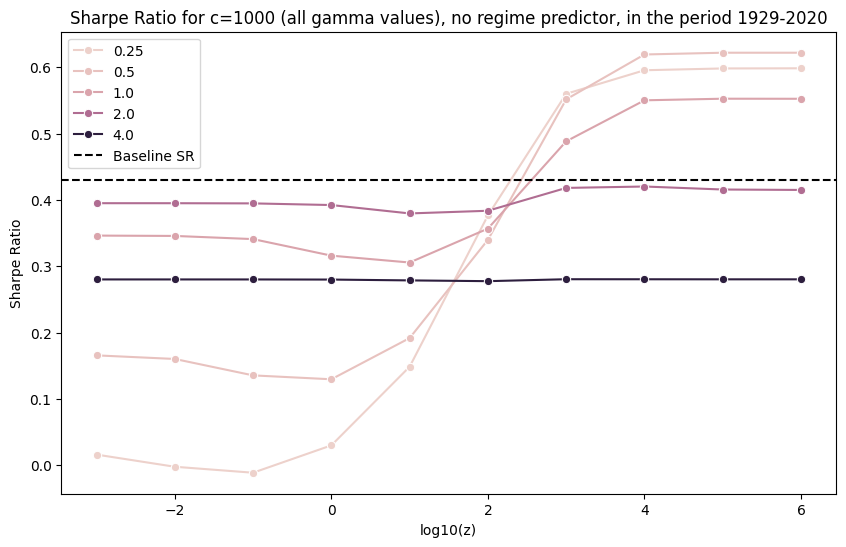

In [202]:

#for c ==1000, plot the sharpes across different gammas and zs in metrics_mean_noregime, show all plots in the same figure with different colors
plt.figure(figsize=(10, 6))

subset = metrics_mean[metrics_mean.c == 1000]

sns.lineplot(
    x="log10(z)",
    y="SR",
    hue="gamma",        # different color per gamma
    data=subset,
    marker="o"
)

plt.title("Sharpe Ratio for c=1000 (all gamma values), no regime predictor, in the period 1929-2020")
plt.xlabel("log10(z)")
plt.ylabel("Sharpe Ratio")
plt.axhline(baseline_dict["SR"], color="black", linestyle="--", label="Baseline SR")
plt.legend()
plt.savefig(PLOTS_DIR / "sharpe_c1000_all_gamma.jpg", bbox_inches="tight")
plt.show()


In [ ]:
#Theres a strong systematic dependency on gamma, even in the original paper, so lets stick to a single gamma value in our regime vs no regime analysys

data_aligned.head()

,b/m,de,dfr,dfy,dp,dy,ep,infl,ltr,lty,ntis,svar,tbl,tms,returns,volRegime_shifted
yyyymm,,,,,,,,,,,,,,,,
1990-02-01,-1.270759,-0.450641,0.065531,-0.362653,-0.853693,-0.849063,-0.431064,0.347088,-0.287771,1.168625,-1.292002,-0.319133,1.201486,-0.321857,0.008539,0
1990-03-01,-0.989209,-0.346430,0.227175,-0.465280,-0.907457,-0.850578,-0.561715,0.473289,-0.373400,1.208286,-1.234963,-0.315070,1.247005,-0.346568,0.024255,0
1990-05-01,-1.111581,-0.215133,-0.282868,-0.335781,-1.042968,-0.768426,-0.788623,-0.050521,1.700034,1.184894,-0.924956,-0.261228,1.195542,-0.263356,0.091989,0
1990-06-01,-1.112742,-0.149841,-0.153080,-0.309767,-0.977861,-1.034912,-0.779980,0.465348,0.863228,1.122462,-0.856925,-0.262769,1.190677,-0.413116,-0.008886,0
1990-08-01,-0.906619,-0.170463,0.989973,-0.257721,-0.589593,-0.950500,-0.408236,1.096668,-2.063891,1.297601,-0.781142,0.464816,1.104076,0.288049,-0.094314,0


In [124]:
from pathlib import Path

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)  # create folder if missing

METRICS_CACHE_FILE_withregime = CACHE_DIR / "metrics_withregime.parquet"

In [ ]:
# Simulating strategies with data_aligned(1990-) instead of data(1929-)

#Making minor changes to speed up the simulation.
#Changes : 
# Load cached results or run simulation

iterations_temp = np.arange(1, 11)

if METRICS_CACHE_FILE_withregime.exists():
    print("Loading cached simulation results...")
    metrics_withregime = pd.read_parquet(METRICS_CACHE_FILE_withregime)
else:
    print("Running simulation with vol regime predictor from 1990-2020 (this may take several hours)...")
    
    def simulation(data, returns, gamma, n_features, ridge_lambda, iteration):
        complexity_ratio = n_features / TRAIN_WINDOW
        rff = RandomFourierFeatures(n_features=int(n_features / 2), gamma=gamma)
        rff_data = rff.transform(data, seed=iteration) 
        
        bt = Backtest(ridge_lambda=ridge_lambda, train_window=TRAIN_WINDOW)
        bt.predict(features=rff_data, returns=returns.shift(-1))
        performance = bt.calc_performance()
        performance.update({
            "gamma": gamma,
            "P": n_features,
            "z": ridge_lambda,
            "c": complexity_ratio,
            "T": TRAIN_WINDOW,
            "iteration": iteration,
        })
        return performance

    metrics_withregime = Parallel(n_jobs=-1, verbose=1)(
        delayed(simulation)(data_aligned, returns_aligned, gamma, P, z, iteration=seed)
        for gamma, P, z, seed in itertools.product(gammas, P_values, z_values, iterations_temp) #hardcoded iterations to 10
    )
    metrics_withregime = pd.DataFrame(metrics_withregime)
    metrics_withregime.to_parquet(METRICS_CACHE_FILE_withregime)

# Aggregate results across iterations
metrics_mean_withregime = metrics_withregime.groupby(["gamma", "P", "z", "c", "T"]).mean().reset_index().drop("iteration", axis=1)
metrics_mean_withregime["log10(z)"] = np.log10(metrics_mean_withregime["z"])


Running simulation with vol regime predictor from 1990-2020 (this may take several hours)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 320 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 820 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 1520 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 2420 tasks      | elapsed:   23.0s
[Parallel(n_jobs=-1)]: Done 3520 tasks      | elapsed:   33.5s
[Parallel(n_jobs=-1)]: Done 4820 tasks      | elapsed:   48.6s
[Parallel(n_jobs=-1)]: Done 6320 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 7530 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 9208 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 11308 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 13608 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done 15338 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 20352 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 22594 tasks  

In [203]:
# Extract results for high complexity regime (gamma=2, z=1000, c=1000)
result_withregime = metrics_mean_withregime[
    (metrics_mean_withregime.gamma == 0.25) & 
    (metrics_mean_withregime.z == 1000) & 
    (metrics_mean_withregime.c == 1000)
][["Expected Return", "R2", "SR", "IR"]].max().to_dict()

print("Our Results (gamma=0.25, z=1000, c=1000):")
for k, v in result_withregime.items():
    print(f"  {k}: {v:.4f}")


Our Results (gamma=0.25, z=1000, c=1000):
  Expected Return: 1.1351
  R2: -0.0432
  SR: 0.7895
  IR: 0.0357


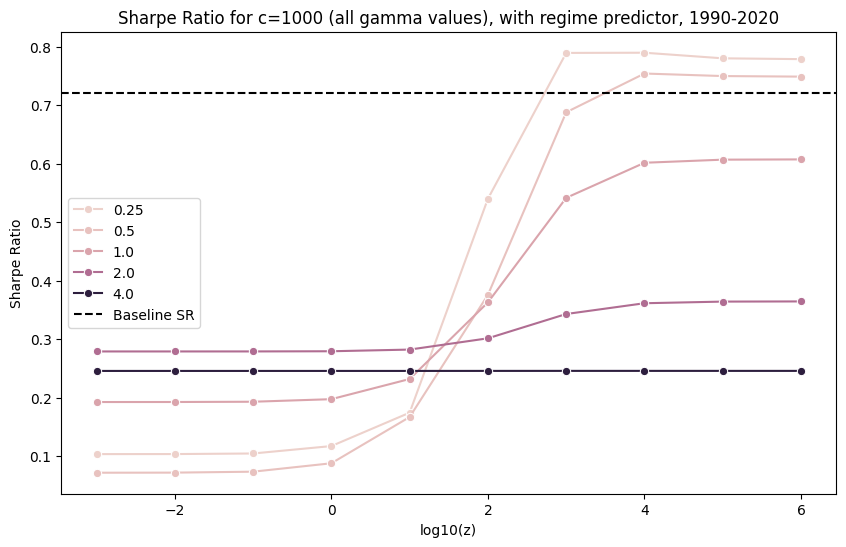

In [204]:
fixed_c = 1000
metrics_mean_withregime[metrics_mean_withregime.c == fixed_c]
#for c ==1000, plot the sharpes across different gammas and zs in metrics_mean_withregime, show all plots in the same figure with different colors
plt.figure(figsize=(10, 6))

subset = metrics_mean_withregime[metrics_mean_withregime.c == fixed_c]
sns.lineplot(
    x="log10(z)",
    y="SR",
    hue="gamma",        # different color per gamma
    data=subset,
    marker="o"
)

plt.title(f"Sharpe Ratio for c={fixed_c} (all gamma values), with regime predictor, 1990-2020")
plt.xlabel("log10(z)")
plt.ylabel("Sharpe Ratio")
plt.axhline(baseline_dict_noregime["SR"], color="black", linestyle="--", label="Baseline SR")
plt.legend()
plt.savefig(PLOTS_DIR / f"sharpe_c{fixed_c}_all_gamma.jpg", bbox_inches="tight")
plt.show()

### **Comparing strategies with vs without the regime predictor**

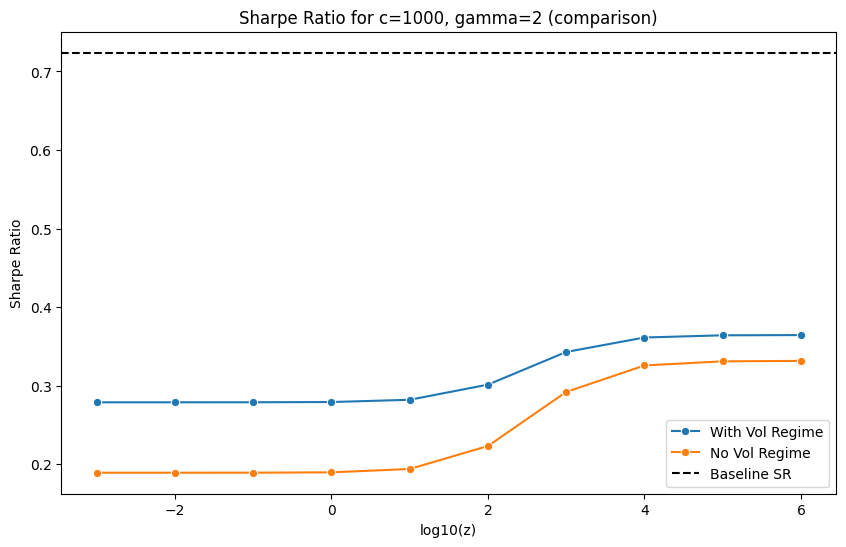

In [182]:
#compare the sharpe ratios for c = 1000, gamma = 0.5, across different zs, between the regime and no regime version
fixed_c = 1000
fixed_gamma = 2
subset_withregime = metrics_mean_withregime[
    (metrics_mean_withregime.c == fixed_c) & 
    (metrics_mean_withregime.gamma == fixed_gamma)
]
subset_noregime = metrics_mean_noregime[
    (metrics_mean_noregime.c == fixed_c) & 
    (metrics_mean_noregime.gamma == fixed_gamma)
]
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="log10(z)",
    y="SR",
    data=subset_withregime,
    marker="o",
    label="With Vol Regime"
)
sns.lineplot(
    x="log10(z)",
    y="SR",
    data=subset_noregime,
    marker="o",
    label="No Vol Regime"
)
plt.title(f"Sharpe Ratio for c={fixed_c}, gamma={fixed_gamma} (comparison)")
plt.xlabel("log10(z)")
plt.ylabel("Sharpe Ratio")
plt.axhline(baseline_dict_noregime["SR"], color="black", linestyle="--", label="Baseline SR")
plt.legend()
plt.savefig(PLOTS_DIR / f"sharpe_c{fixed_c}_gamma{fixed_gamma}_comparison.jpg", bbox_inches="tight")
plt.show()

#### **Observations:**
##### There is a clear improvement in sharpe by including a simple volRegime factor using VIX as reference, regimeFactor used :-1 for VIX <=15, 1 for VIX >= 25, 0 else


### **To do next:** 
#### 1. Understand why the performance is consistently better for low gamma.
#### 2. Since there is an advantage for regime factor, Integrate HMMs and find the regimes from the data, instead just using a vol regime by VIX